# Расследование II-04 · Карта дорогих ошибок

**Бюро аналитических расследований, 10–13 апреля 2026 года.** Поставщик «Компаса» утверждает, что модель оценки жилья «работает в новых районах Калифорнии». Вера Орлова просит проверить не красивое общее число, а именно это обещание.

Вы сравните случайное и групповое по географии разбиения. При случайном соседние кварталы могут оказаться по обе стороны границы; при групповом целые пространственные ячейки остаются невиданными. Это разница между интерполяцией рядом со знакомыми местами и переносом в новый регион.

**Для кого:** студент после расследований II-01–II-03. Нужны DataFrame, разбиение на обучающую и тестовую выборки, конвейеры и базовые метрики классификации; регрессия вводится с нуля.

**Результат:** базовая модель, линейная модель и случайный лес; MAE, RMSE и $R^2$; остатки, карта ошибок, ценовые и географические срезы; пятичастная аудиторская записка.


## Маршрут расследования

1. Проверить локальный снимок California Housing и ограничение целевой переменной.
2. Зафиксировать случайную тестовую выборку и географические группы.
3. Сравнить три модели в одинаковых условиях.
4. Перевести метрики из единиц датасета в доллары.
5. Найти структуру в остатках и срезах.
6. Отделить установленный факт от неподтверждённого обещания.

Ориентир времени — 4–5 часов. Внешняя тестовая выборка не используется для выбора гиперпараметров.


In [1]:
from __future__ import annotations

import hashlib
import random
import urllib.request
import zipfile
from pathlib import Path

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
NOTEBOOK_VARIANT = "solution"
CASE_SLUG = "case-04"
ARCHIVE_NAME = "part-2-case-04.zip"
COURSE_SITE = "https://mkuziuk.github.io/python-tutorial"
IN_COLAB = False

# При локальном запуске используем файлы из каталога расследования; в Colab скачиваем архив и проверяем его SHA-256.
# Импорт google.colab проходит только в Colab; локально возникает ImportError, и IN_COLAB остаётся False.
try:
    import google.colab  # type: ignore[import-not-found]  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def find_local_case() -> Path | None:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "README.md").is_file()
            and (candidate / f"{CASE_SLUG}.ipynb").is_file()
        ):
            return candidate
        nested = candidate / "projects" / "part-2" / CASE_SLUG
        if (nested / "README.md").exists():
            return nested
    return None

def download_colab_case() -> Path:
    destination = Path("/content") / f"python-tutorial-{CASE_SLUG}"
    destination.mkdir(parents=True, exist_ok=True)
    archive_path = destination / ARCHIVE_NAME
    archive_url = f"{COURSE_SITE}/downloads/{ARCHIVE_NAME}"
    checksum_url = f"{archive_url}.sha256"

    urllib.request.urlretrieve(archive_url, archive_path)
    # Сравниваем SHA-256 архива с опубликованной контрольной суммой перед распаковкой.
    with urllib.request.urlopen(checksum_url) as response:
        expected = response.read().decode("utf-8").split()[0].lower()
    actual = sha256_file(archive_path)
    if actual != expected:
        raise RuntimeError(f"SHA-256 архива не совпал: {actual} != {expected}")

    unpacked = destination / "unpacked"
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(unpacked)
    matches = sorted(unpacked.rglob(f"{CASE_SLUG}.ipynb"))
    if not matches:
        raise FileNotFoundError(f"В архиве нет {CASE_SLUG}.ipynb")
    return matches[0].parent

# DATA_DIR и ARTIFACTS_DIR строятся от найденного каталога расследования, поэтому текущая папка не влияет на пути.
CASE_DIR = find_local_case()
if CASE_DIR is None and IN_COLAB:
    CASE_DIR = download_colab_case()
if CASE_DIR is None:
    raise FileNotFoundError(
        f"Не найден каталог {CASE_SLUG}. Запустите тетрадь из каталога расследования."
    )

DATA_DIR = CASE_DIR / "data"
ARTIFACTS_DIR = CASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)
print(f"Среда: {'Colab' if IN_COLAB else 'local'} | расследование: {CASE_DIR}")
print(f"RANDOM_STATE = {RANDOM_STATE}")


Среда: local | расследование: /private/var/folders/fv/ts0wlkms131g6wghvr6zgnpm0000gn/T/python-tutorial-part2-run-y2wh8jce/case-04
RANDOM_STATE = 42


In [2]:
import json
import warnings
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

def display_figure(fig):
    """Сохранить график в output даже при неинтерактивном backend."""
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)


## 1. Карточка источника и контроль целостности

Бюро поставляет фиксированный CSV: 20 640 блок-групп переписи 1990 года, восемь числовых признаков и `MedHouseVal`. Целевая переменная измеряется в сотнях тысяч долларов. Файл получен через `fetch_california_housing` и больше не зависит от сети.

`SOURCE.md`, `LICENSE.txt` и `dataset_manifest.json` фиксируют происхождение, версию конвертации и SHA-256. Сначала проверяем байты, только потом строим выводы.


In [3]:
manifest = json.loads((DATA_DIR / "dataset_manifest.json").read_text(encoding="utf-8"))
data_path = DATA_DIR / manifest["filename"]
actual_digest = sha256_file(data_path)
assert actual_digest == manifest["sha256"], "Снимок данных изменился"

housing = pd.read_csv(data_path)
assert housing.shape == (20_640, 9)
display(housing.head())
print(f"Строк: {len(housing):,}; пропусков: {int(housing.isna().sum().sum())}")


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Строк: 20,640; пропусков: 0


**Разбор результата.** `housing` имеет форму `(20640, 9)`: восемь столбцов станут признаками, а `MedHouseVal` — целевой переменной. Нулевая сумма пропусков подтверждает, что этому снимку не нужна отдельная стратегия заполнения. Проверка SHA-256 доказывает только совпадение файла с манифестом, но не актуальность переписи 1990 года. Мы установили границу источника и теперь проверим диапазоны и верхнее ограничение target.

In [4]:
audit = pd.DataFrame({
    "dtype": housing.dtypes.astype(str),
    "missing": housing.isna().sum(),
    "minimum": housing.min(numeric_only=True),
    "median": housing.median(numeric_only=True),
    "maximum": housing.max(numeric_only=True),
})
display(audit.round(3))

target_cap = float(manifest["target_cap"])
capped_count = int(np.isclose(housing["MedHouseVal"], target_cap).sum())
print(f"Строк на верхней границе target {target_cap}: {capped_count}")


,dtype,missing,minimum,median,maximum
MedInc,float64,0,0.500,3.535,15.000
HouseAge,float64,0,1.000,29.000,52.000
AveRooms,float64,0,0.846,5.229,141.909
AveBedrms,float64,0,0.333,1.049,34.067
Population,float64,0,3.000,1166.000,35682.000
AveOccup,float64,0,0.692,2.818,1243.333
Latitude,float64,0,32.540,34.260,41.950
Longitude,float64,0,-124.350,-118.490,-114.310
MedHouseVal,float64,0,0.150,1.797,5.000


Строк на верхней границе target 5.00001: 992


**Разбор результата.** Таблица `audit` связывает каждый столбец с типом, числом пропусков и диапазоном. `capped_count` показывает более 900 строк ровно на `5.00001`, то есть наблюдаемая цена не различает объекты выше примерно 500 000 долларов. Это не позволяет восстановить истинный разброс дорогого сегмента. Следующий график проверит, как граница выглядит в распределении и связана ли цель с координатами.

Верхняя граница — не просто неудобный выброс: значения выше примерно 500 000 долларов были сведены к одному числу. Поэтому модель не может научиться различать дорогие объекты за этой границей, а ошибки в верхнем ценовом срезе искусственно искажены. Это ограничение данных, не свойство алгоритма.


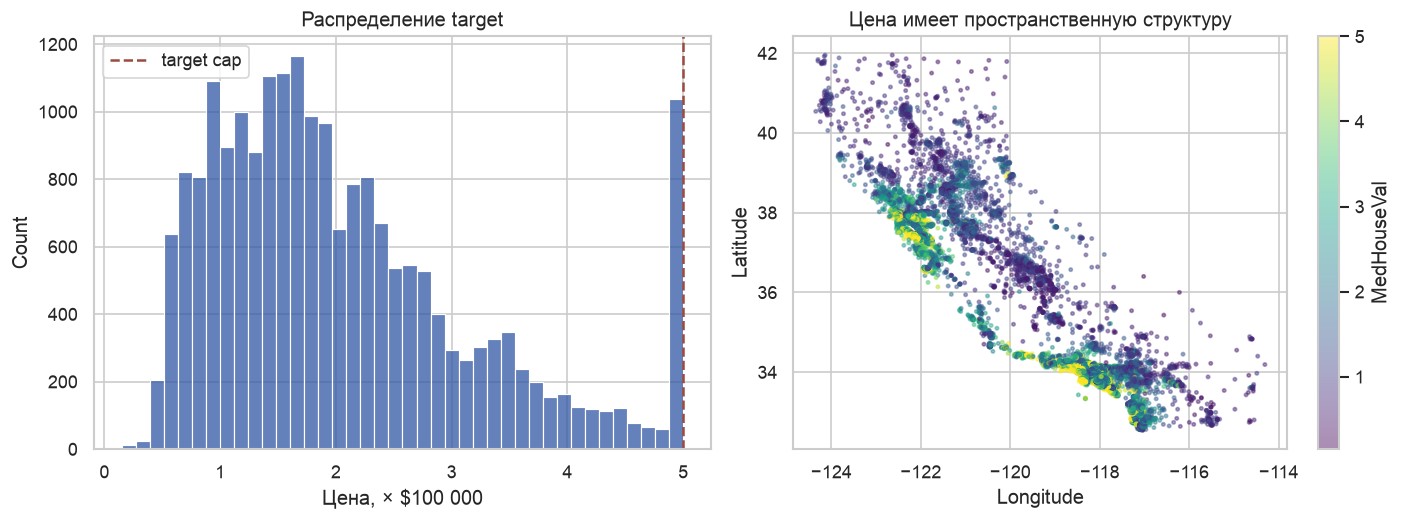

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(housing, x="MedHouseVal", bins=40, ax=axes[0], color="#3157a4")
axes[0].axvline(target_cap, color="#9b4b3f", linestyle="--", label="target cap")
axes[0].set(title="Распределение target", xlabel="Цена, × $100 000")
axes[0].legend()
scatter = axes[1].scatter(
    housing["Longitude"], housing["Latitude"],
    c=housing["MedHouseVal"], s=4, alpha=0.45, cmap="viridis"
)
axes[1].set(title="Цена имеет пространственную структуру", xlabel="Longitude", ylabel="Latitude")
fig.colorbar(scatter, ax=axes[1], label="MedHouseVal")
plt.tight_layout()
display_figure(fig)


**Интерпретация EDA.** Гистограмма заканчивается заметным скоплением у `target_cap`, а карта показывает пространственные кластеры цены. Наблюдение поддерживает проверку по географическим группам: случайное перемешивание может оставить соседние и похожие кварталы по обе стороны split. Карта не доказывает, что координаты причинно определяют цену, и не задаёт правильный размер региона. Поэтому заранее сравним две разные границы проверки.

## 2. Постановка и две границы проверки

Мы предсказываем непрерывную величину. Для ошибки $e_i=y_i-\hat y_i$:

- $MAE=\frac{1}{n}\sum|e_i|$ — типичная абсолютная ошибка;
- $RMSE=\sqrt{\frac{1}{n}\sum e_i^2}$ — сильнее штрафует большие промахи;
- $R^2=1-\frac{\sum e_i^2}{\sum(y_i-\bar y)^2}$ — доля вариации относительно базового прогноза среднего.

MAE и RMSE здесь умножаем на 100 000, чтобы вернуть доллары. $R^2$ не имеет единицы и может быть отрицательным.


In [6]:
target_column = "MedHouseVal"
X = housing.drop(columns=target_column)
y = housing[target_column]
all_positions = np.arange(len(housing))

# Случайное разбиение проверяет интерполяцию рядом со знакомыми регионами.
random_train, random_test = train_test_split(
    all_positions, test_size=0.20, random_state=RANDOM_STATE
)
print(f"Случайный split: train={len(random_train):,}, тест={len(random_test):,}")


Случайный split: train=16,512, тест=4,128


**Граница случайной проверки.** Получены 16 512 обучающих и 4 128 тестовых строк. Такое разбиение оценивает прогноз для случайно выбранного квартала из той же смеси мест, но не гарантирует независимость соседних областей. Чтобы отдельно проверить перенос, нужна единица независимости крупнее строки; далее ею станет заранее заданная ячейка 0,5° × 0,5°.

### Упражнение: единица независимости — регион

Создайте ячейку примерно 0,5° × 0,5° из longitude и latitude. Затем `GroupShuffleSplit` должен удержать все строки одной ячейки только с одной стороны границы. Проверьте пересечение множеств групп явно.


In [7]:
# BEGIN SOLUTION
# Объединяем координаты в ячейки 0,5° × 0,5° и используем идентификатор ячейки как группу.
longitude_bin = np.floor((X["Longitude"] + 125.0) * 2).astype(int)
latitude_bin = np.floor((X["Latitude"] - 32.0) * 2).astype(int)
region_groups = longitude_bin.astype(str) + "_" + latitude_bin.astype(str)
# END SOLUTION

region_splitter = GroupShuffleSplit(
    n_splits=1, test_size=0.20, random_state=RANDOM_STATE
)
# split() возвращает последовательность разбиений; next() получает единственную пару индексов.
grouped_train, grouped_test = next(
    region_splitter.split(X, y, groups=region_groups)
)
# group_overlap должен быть пустым перед оценкой модели.
group_overlap = set(region_groups.iloc[grouped_train]) & set(region_groups.iloc[grouped_test])
print(
    f"Групп: {region_groups.nunique()}, train={len(grouped_train):,}, "
    f"test={len(grouped_test):,}, пересечение={len(group_overlap)}"
)


Групп: 176, train=16,987, test=3,653, пересечение=0


**Граница региональной проверки.** `region_groups` сопоставляет каждой строке строковый ключ вида `longitude_bin_latitude_bin`. Нулевое `group_overlap` подтверждает, что одна географическая ячейка не попала одновременно в обучение и тест. Один `GroupShuffleSplit` всё же не описывает все возможные регионы и не служит выборкой для настройки. Теперь обе границы зафиксированы, поэтому один и тот же набор моделей можно сравнить без подгонки по тесту.

## 3. Три уровня сложности

`DummyRegressor` всегда предсказывает среднее обучающей выборки и задаёт нижнюю планку. Линейная регрессия проверяет простую глобальную зависимость. Случайный лес улавливает нелинейности, но особенно легко пользуется похожими соседними строками — поэтому смена разбиения важна.

**Упражнение:** клонируйте и обучите каждую модель только на обучающей выборке; верните таблицу метрик, предсказания и обученные объекты.


In [8]:
model_suite = {
    "dummy_mean": DummyRegressor(strategy="mean"),
    "linear": make_pipeline(StandardScaler(), LinearRegression()),
    "random_forest": RandomForestRegressor(
        n_estimators=120,
        min_samples_leaf=2,
        max_features=0.8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

# BEGIN SOLUTION
# Один набор моделей оцениваем на случайном и географическом разбиениях.
def evaluate_suite(train_positions, test_positions):
    rows, predictions, fitted_models = [], {}, {}
    for model_name, template in model_suite.items():
        # clone(template) создаёт новую необученную модель без состояния предыдущего разбиения.
        fitted = clone(template).fit(X.iloc[train_positions], y.iloc[train_positions])
        predicted = fitted.predict(X.iloc[test_positions])
        rows.append({
            "model": model_name,
            "mae": mean_absolute_error(y.iloc[test_positions], predicted),
            "rmse": root_mean_squared_error(y.iloc[test_positions], predicted),
            "r2": r2_score(y.iloc[test_positions], predicted),
        })
        predictions[model_name] = predicted
        fitted_models[model_name] = fitted
    return pd.DataFrame(rows).set_index("model"), predictions, fitted_models
# END SOLUTION

random_results, random_predictions, random_fitted = evaluate_suite(
    random_train, random_test
)
# MAE и RMSE измеряются в сотнях тысяч долларов; умножение на 100 000 переводит их в доллары.
display(random_results.assign(
    mae_usd=random_results["mae"] * 100_000,
    rmse_usd=random_results["rmse"] * 100_000,
).round(3))


,mae,rmse,r2,mae_usd,rmse_usd
model,,,,,
dummy_mean,0.906,1.145,-0.000,90606.855,114485.635
linear,0.533,0.746,0.576,53320.013,74558.138
random_forest,0.326,0.504,0.806,32588.289,50359.732


**Сравнение на случайном holdout.** `DummyRegressor` задаёт baseline средним обучающей выборки; линейная модель проверяет глобальную линейную зависимость, а лес — нелинейные взаимодействия. У леса 120 деревьев для устойчивого учебного результата, `min_samples_leaf=2` ограничивает подгонку единичных строк, а `max_features=0.8` немного декоррелирует деревья; эти значения зафиксированы до просмотра holdout. Таблица показывает входную границу из 16 512 строк и по 4 128 прогнозов каждой модели. Лес выигрывает у baseline, но это пока свидетельство об интерполяции, поэтому повторяем без изменения моделей на невиданных ячейках.

In [9]:
grouped_results, grouped_predictions, grouped_fitted = evaluate_suite(
    grouped_train, grouped_test
)
comparison = pd.concat(
    {"random_holdout": random_results, "region_holdout": grouped_results},
    names=["split", "model"],
)
display(comparison.assign(
    mae_usd=comparison["mae"] * 100_000,
    rmse_usd=comparison["rmse"] * 100_000,
).round(3))


mae   rmse     r2    mae_usd    rmse_usd
split          model                                                    
random_holdout dummy_mean     0.906  1.145 -0.000  90606.855  114485.635
               linear         0.533  0.746  0.576  53320.013   74558.138
               random_forest  0.326  0.504  0.806  32588.289   50359.732
region_holdout dummy_mean     0.941  1.179 -0.004  94118.519  117906.609
               linear         0.566  0.769  0.573  56624.048   76922.849
               random_forest  0.489  0.660  0.686  48896.621   65959.023

**Интерпретация сравнения.** `comparison` использует одинаковые MAE, RMSE и $R^2$ для двух вопросов. У случайного леса RMSE около 0,50 (примерно 50 000 долларов) на случайном holdout и около 0,66 (примерно 66 000 долларов) на региональном; рост больше 0,08 показывает, что обещание о новых регионах поддержано слабее. Один split не даёт доверительного интервала и не доказывает провал в каждом регионе. Чтобы увидеть, какие наблюдения создают разрыв, далее рассматриваем знаковые остатки.

## 4. Остатки и карта промахов

Общая метрика отвечает «сколько в среднем», но не «где» и не «для каких цен». Остаток определяем как `y_true - y_pred`: положительный означает недооценку, отрицательный — переоценку.


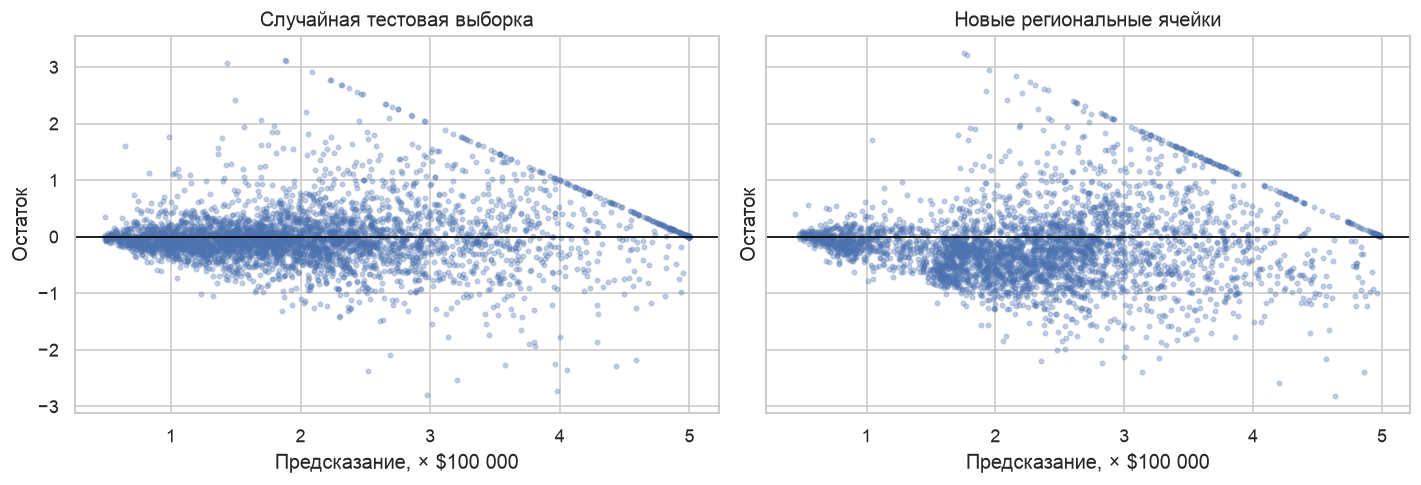

In [10]:
random_residuals = y.iloc[random_test].to_numpy() - random_predictions["random_forest"]
grouped_residuals = y.iloc[grouped_test].to_numpy() - grouped_predictions["random_forest"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
axes[0].scatter(random_predictions["random_forest"], random_residuals, s=7, alpha=0.3)
axes[1].scatter(grouped_predictions["random_forest"], grouped_residuals, s=7, alpha=0.3)
for ax, title in zip(
    axes,
    ["Случайная тестовая выборка", "Новые региональные ячейки"],
    strict=True,
):
    ax.axhline(0, color="black", linewidth=1)
    ax.set(title=title, xlabel="Предсказание, × $100 000", ylabel="Остаток")
plt.tight_layout()
display_figure(fig)


**Интерпретация остатков.** Облако регионального holdout шире отклоняется от нулевой линии, чем облако случайного, что согласуется с ростом RMSE. Знак показывает направление ошибки: точки выше нуля недооценены, ниже — переоценены. График выявляет структуру, но не объясняет её причину, а верхняя граница target искажает картину дорогих объектов. Следующий шаг переводит абсолютную величину тех же остатков в доллары и возвращает ей координаты.

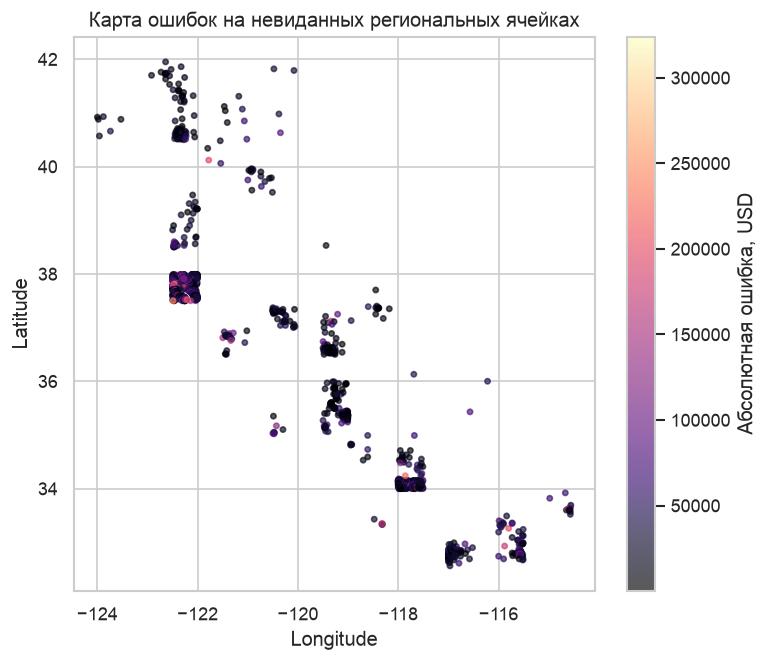

In [11]:
map_frame = X.iloc[grouped_test][["Longitude", "Latitude"]].copy()
map_frame["absolute_error_usd"] = np.abs(grouped_residuals) * 100_000

fig, ax = plt.subplots(figsize=(7, 6))
points = ax.scatter(
    map_frame["Longitude"],
    map_frame["Latitude"],
    c=map_frame["absolute_error_usd"],
    s=10,
    alpha=0.65,
    cmap="magma",
)
fig.colorbar(points, ax=ax, label="Абсолютная ошибка, USD")
ax.set(
    title="Карта ошибок на невиданных региональных ячейках",
    xlabel="Longitude",
    ylabel="Latitude",
)
display_figure(fig)


**Интерпретация карты.** `map_frame` содержит одну строку на объект регионального теста: координаты и `absolute_error_usd`. Неравномерные тёмные и светлые области показывают, что одна средняя метрика скрывает географическую концентрацию промахов. Это ассоциация места с ошибкой, а не доказательство влияния конкретного района или признака. Для количественного сравнения агрегируем ошибки в заранее понятные ценовые и north/south срезы и обязательно сохраняем их размер.

### Упражнение: агрегат скрывает срезы

Сравните MAE по квартилям истинной цены и по северной/южной части групповой тестовой выборки. Обязательно показывайте `n`: маленький срез даёт нестабильную оценку.


In [12]:
slice_frame = X.iloc[grouped_test][["Latitude", "Longitude"]].copy()
slice_frame["actual"] = y.iloc[grouped_test].to_numpy()
slice_frame["prediction"] = grouped_predictions["random_forest"]
slice_frame["absolute_error_usd"] = np.abs(
    slice_frame["actual"] - slice_frame["prediction"]
) * 100_000

slice_frame["price_quartile"] = pd.qcut(
    slice_frame["actual"], 4, labels=["Q1", "Q2", "Q3", "Q4"]
)
slice_frame["geography"] = np.where(
    slice_frame["Latitude"] >= 37.0, "north", "south"
)
price_slices = slice_frame.groupby("price_quartile", observed=True).agg(
    n=("actual", "size"), mae_usd=("absolute_error_usd", "mean")
)
geography_slices = slice_frame.groupby("geography").agg(
    n=("actual", "size"), mae_usd=("absolute_error_usd", "mean")
)
display(price_slices.round(0))
display(geography_slices.round(0))


,n,mae_usd
price_quartile,,
Q1,914,44618.0
Q2,913,46806.0
Q3,913,38062.0
Q4,913,66105.0


,n,mae_usd
geography,,
north,2389,56330.0
south,1264,34847.0


**Интерпретация срезов.** `price_slices` сравнивает четыре приблизительно равных по числу наблюдений квартиля истинной цены, а `geography_slices` использует фиксированную границу широты 37°. Столбец `n` нужен рядом с `mae_usd`: средняя ошибка малой группы менее стабильна. Различия показывают, где требуется дополнительная проверка, но не устанавливают причинность и зависят от одного регионального split. Эти границы переходят в аудиторскую записку вместе с агрегатными метриками.

## 5. Аудиторская записка

Записка обязана разделять пять вещей: установленный факт, поддержанную интерпретацию, что не доказано, ограничения и действие. Нельзя превращать пространственную корреляцию в причинное объяснение цены.


In [13]:
# BEGIN SOLUTION
memo = {
    "established_fact": (
        "На фиксированном снимке random forest превосходит baseline, но его RMSE "
        "на региональном holdout заметно выше, чем на случайном."
    ),
    "supported_interpretation": (
        "Случайный split измеряет главным образом интерполяцию среди географически "
        "похожих кварталов и завышает поддержку заявления о новых регионах."
    ),
    "not_proven": (
        "Анализ не доказывает причин цены, пригодности для текущего рынка или "
        "умышленного введения в заблуждение конкретным сотрудником."
    ),
    "limitations": (
        "Перепись 1990 года устарела; target top-coded; один групповой split и грубые "
        "ячейки не описывают все варианты географического переноса."
    ),
    "recommended_action": (
        "Отклонить формулировку «работает в новых районах» до независимой проверки "
        "на заранее определённых регионах и публиковать карты и срезы ошибок."
    ),
}
# END SOLUTION

memo_text = "# Аудиторская записка II-04\n\n" + "\n\n".join(
    f"## {key}\n{value}" for key, value in memo.items()
) + "\n"
(ARTIFACTS_DIR / "audit_memo.md").write_text(memo_text, encoding="utf-8")
print(memo_text)


# Аудиторская записка II-04

## established_fact
На фиксированном снимке random forest превосходит baseline, но его RMSE на региональном holdout заметно выше, чем на случайном.

## supported_interpretation
Случайный split измеряет главным образом интерполяцию среди географически похожих кварталов и завышает поддержку заявления о новых регионах.

## not_proven
Анализ не доказывает причин цены, пригодности для текущего рынка или умышленного введения в заблуждение конкретным сотрудником.

## limitations
Перепись 1990 года устарела; target top-coded; один групповой split и грубые ячейки не описывают все варианты географического переноса.

## recommended_action
Отклонить формулировку «работает в новых районах» до независимой проверки на заранее определённых регионах и публиковать карты и срезы ошибок.



In [14]:
if NOTEBOOK_VARIANT == "solution":
    expected_memo_keys = {
        "established_fact",
        "supported_interpretation",
        "not_proven",
        "limitations",
        "recommended_action",
    }
    memo_path = ARTIFACTS_DIR / "audit_memo.md"

    assert not group_overlap
    assert random_results.loc["random_forest", "rmse"] < random_results.loc["dummy_mean", "rmse"]
    assert grouped_results.loc["random_forest", "rmse"] > random_results.loc["random_forest", "rmse"] + 0.08
    assert capped_count > 900
    assert set(memo) == expected_memo_keys
    assert all(isinstance(value, str) and len(value.strip()) >= 40 for value in memo.values())
    assert not price_slices.empty and not geography_slices.empty
    assert {"n", "mae_usd"} <= set(price_slices.columns)
    assert {"n", "mae_usd"} <= set(geography_slices.columns)
    assert (price_slices["n"] > 0).all() and (geography_slices["n"] > 0).all()
    assert memo_path.is_file() and memo_path.read_text(encoding="utf-8") == memo_text
    print("Проверки решения II-04 пройдены.")
else:
    print("Учебный вариант: строгие проверки включатся после сверки с решением.")


Проверки решения II-04 пройдены.


## Расследование закрыто

Перезапустите ядро и выполните **Run All**. Сверьте форму результата с `check_result.md`: целостность снимка, нулевое пересечение регионов, базовую модель, метрики в долларах, остатки, карта, срезы с `n` и пятичастная записка.

**Типичная ошибка:** увидеть худший групповой результат и начать подбирать размер ячейки по тестовой выборке. Границу проверки определяют до оценки; иначе новая тестовая выборка тоже становится частью обучения.

**Расширение:** повторите групповое разбиение для нескольких заранее объявленных начальных значений генератора и покажите диапазон метрик, не меняя модель по результатам тестовой выборки.
